In [3]:
import json

import gc_utils
import gizmo_analysis as gizmo
import halo_analysis as halo
import matplotlib.pyplot as plt
import numpy as np
import numpy.ma as ma
import pandas as pd
from matplotlib import colors

In [4]:
sim = "m12i"
# sim_dir = "/Users/z5114326/Documents/simulations/"
sim_dir = "/Volumes/Expansion/simulations/"

sim_code_file = sim_dir + "simulation_codes.json"
with open(sim_code_file, "r") as file:
    sim_codes = json.load(file)

pub_data = sim_dir + "snapshot_times_public.txt"
pub_snaps = pd.read_table(pub_data, comment="#", header=None, sep=r"\s+")
pub_snaps.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]

In [5]:
sim_lst = ["m12b", "m12c", "m12f", "m12i", "m12m"]
# sim_lst = ["m12i"]

snap_min = 120
snap_max = 590
snap_lst = np.arange(snap_min, snap_max + 1)
snap_lst = np.arange(snap_min, snap_max + 1, 20)

cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in np.linspace(0, 1, len(sim_lst))]

sim_dict = {sim: {"rad": [], "mas": [], "num": [], "acc": []} for sim in sim_lst}

for sim in sim_lst:
    fire_dir = sim_dir + sim + "/" + sim + "_res7100"
    halt = gc_utils.get_halo_tree(sim, sim_dir)
    main_halo = sim_codes[sim]["halo"]

    for snap in snap_lst:
        halo_tid = gc_utils.get_halo_prog_at_snap(halt, main_halo, snap)
        halo_tidx = np.where(halt["tid"] == halo_tid)[0][0]
        halo_cidx = halt["catalog.index"][halo_tidx]
        hal = halo.io.IO.read_catalogs("index", snap, fire_dir)
        rad = hal["radius"][halo_cidx]
        mas = hal["mass"][halo_cidx]
        num = np.sum(hal.prop("host.distance.total") <= 50) - 1
        acc = hal["accrete.rate"][[halo_cidx]]

        sim_dict[sim]["rad"].append(rad)
        sim_dict[sim]["mas"].append(mas)
        sim_dict[sim]["num"].append(num)
        sim_dict[sim]["acc"].append(acc)

Retrieving Halo Tree.....................: 100%|████████████████████████████████████████████████████████████████████████| 1/1 [00:34<00:00, 34.44s/it]



# in utilities.simulation.Snapshot():
* reading:  Volumes/Expansion/simulations/m12b/m12b_res7100/snapshot_times.txt

  using snapshot index = 120, redshift = 3.000

* read 74418 halos from:  Volumes/Expansion/simulations/m12b/m12b_res7100/halo/rockstar_dm/catalog_hdf5/halo_120.hdf5

# in halo_analysis.halo_io.Particle():
* read 74418 halos, 235 have star particles, from:  Volumes/Expansion/simulations/m12b/m12b_res7100/halo/rockstar_dm/catalog_hdf5/star_120.hdf5
* assigning primary host and coordinates wrt it to halo catalog...  finished


# in utilities.simulation.Snapshot():
* reading:  Volumes/Expansion/simulations/m12b/m12b_res7100/snapshot_times.txt

  using snapshot index = 140, redshift = 2.545

* read 70770 halos from:  Volumes/Expansion/simulations/m12b/m12b_res7100/halo/rockstar_dm/catalog_hdf5/halo_140.hdf5

# in halo_analysis.halo_io.Particle():
* read 70770 halos, 207 have star particles, from:  Volumes/Expansion/simulations/m12b/m12b_res7100/halo/rockstar_dm/catalog_hdf

Retrieving Halo Tree.....................:   0%|                                                                                | 0/1 [00:00<?, ?it/s]


# in halo_analysis.halo_io.Particle():
* read 39804 halos, 61 have star particles, from:  Volumes/Expansion/simulations/m12b/m12b_res7100/halo/rockstar_dm/catalog_hdf5/star_580.hdf5
* assigning primary host and coordinates wrt it to halo catalog...  finished



Retrieving Halo Tree.....................: 100%|████████████████████████████████████████████████████████████████████████| 1/1 [01:21<00:00, 81.40s/it]


...

Retrieving Halo Tree.....................:   0%|                                                                                | 0/1 [00:00<?, ?it/s]


# in halo_analysis.halo_io.Particle():
* read 36073 halos, 51 have star particles, from:  Volumes/Expansion/simulations/m12i/m12i_res7100/halo/rockstar_dm/catalog_hdf5/star_580.hdf5
* assigning primary host and coordinates wrt it to halo catalog...  finished



Retrieving Halo Tree.....................: 100%|████████████████████████████████████████████████████████████████████████| 1/1 [01:14<00:00, 74.79s/it]



# in utilities.simulation.Snapshot():
* reading:  Volumes/Expansion/simulations/m12m/m12m_res7100/snapshot_times.txt

  using snapshot index = 120, redshift = 3.000

* read 145614 halos from:  Volumes/Expansion/simulations/m12m/m12m_res7100/halo/rockstar_dm/catalog_hdf5/halo_120.hdf5

# in halo_analysis.halo_io.Particle():
* read 145614 halos, 424 have star particles, from:  Volumes/Expansion/simulations/m12m/m12m_res7100/halo/rockstar_dm/catalog_hdf5/star_120.hdf5
* assigning primary host and coordinates wrt it to halo catalog...  finished


# in utilities.simulation.Snapshot():
* reading:  Volumes/Expansion/simulations/m12m/m12m_res7100/snapshot_times.txt

  using snapshot index = 140, redshift = 2.545

* read 139040 halos from:  Volumes/Expansion/simulations/m12m/m12m_res7100/halo/rockstar_dm/catalog_hdf5/halo_140.hdf5

# in halo_analysis.halo_io.Particle():
* read 139040 halos, 369 have star particles, from:  Volumes/Expansion/simulations/m12m/m12m_res7100/halo/rockstar_dm/catalog


# in halo_analysis.halo_io.Particle():
* read 81760 halos, 145 have star particles, from:  Volumes/Expansion/simulations/m12m/m12m_res7100/halo/rockstar_dm/catalog_hdf5/star_580.hdf5
* assigning primary host and coordinates wrt it to halo catalog...  finished



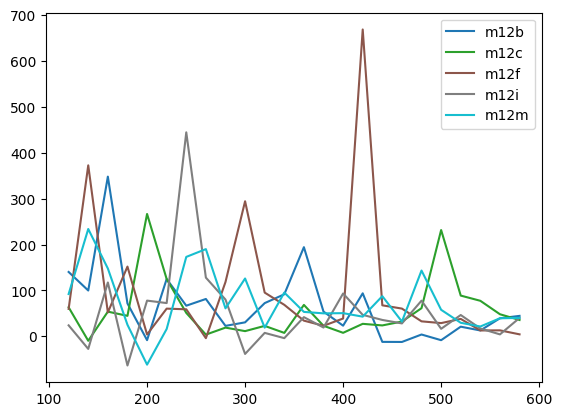

In [9]:
for i, sim in enumerate(sim_lst):
    # vol = (4 * np.pi / 3) * np.array(sim_dict[sim]["rad"]) ** 3
    # val = np.array(sim_dict[sim]["mas"]) / vol
    val = np.array(sim_dict[sim]["acc"])
    plt.plot(snap_lst, val, c=colors[i], label=sim)

# plt.yscale("log")
plt.legend()